In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency,chisquare

In [11]:
DATA_PATH=Path('data/clean_cookie_cats.csv')
df=pd.read_csv(DATA_PATH)
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90094,9999441,gate_40,97,True,False
90095,9999479,gate_40,30,False,False
90096,9999710,gate_30,28,True,False
90097,9999768,gate_40,51,True,False


## Chi2

In [12]:
ctab_07 = pd.crosstab(df['version'], df['retention_7'])
print("Contingency Table:")
print(ctab_07)

Contingency Table:
retention_7  False  True 
version                  
gate_30      36198   8461
gate_40      37209   8231


In [13]:
stat, p, dof, expected = chi2_contingency(ctab_07)

print(f"\nChi-square Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected {expected}")



Chi-square Statistic: 10.2691
P-value: 0.0014
Degrees of Freedom: 1
Expected [[36385.34515366  8273.65484634]
 [37021.65484634  8418.34515366]]


In [14]:
ctab_01 = pd.crosstab(df['version'], df['retention_1'])
print("Contingency Table:")
print(ctab_01)

Contingency Table:
retention_1  False  True 
version                  
gate_30      24665  19994
gate_40      25368  20072


In [15]:
stat, p, dof, expected = chi2_contingency(ctab_01)

print(f"\nChi-square Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected {expected}")


Chi-square Statistic: 3.2357
P-value: 0.0720
Degrees of Freedom: 1
Expected [[24799.65090623 19859.34909377]
 [25233.34909377 20206.65090623]]


In [16]:
df_1d=[]
df_7d=[]

for i in range(500):
    df_mean_1=df.sample(frac=1, replace=True).groupby('version')['retention_1'].mean()
    df_mean_7=df.sample(frac=1, replace=True).groupby('version')['retention_7'].mean()
    df_1d.append(df_mean_1)
    df_7d.append(df_mean_7)

df_1d=pd.DataFrame(df_1d)
df_7d=pd.DataFrame(df_7d)

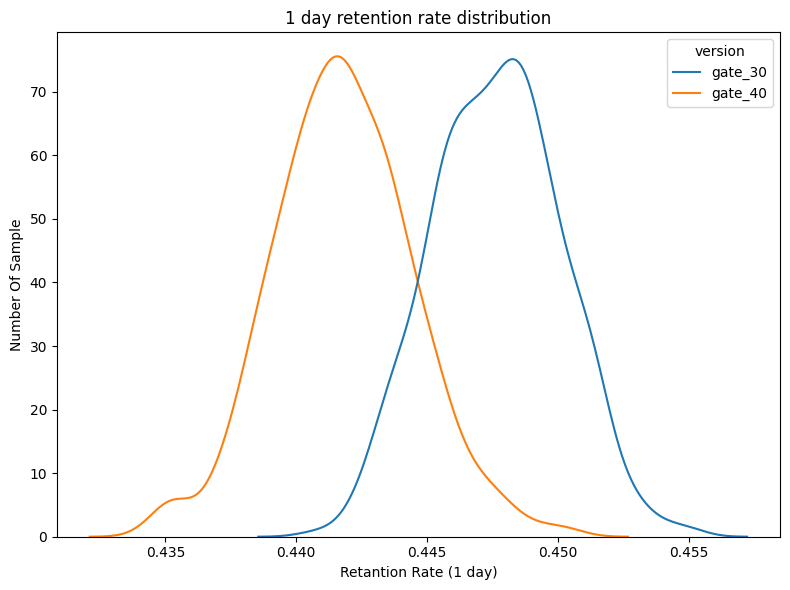

In [17]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df_1d)
plt.title("1 day retention rate distribution")
plt.xlabel('Retantion Rate (1 day)')
plt.ylabel('Number Of Sample')
plt.tight_layout()
plt.show()

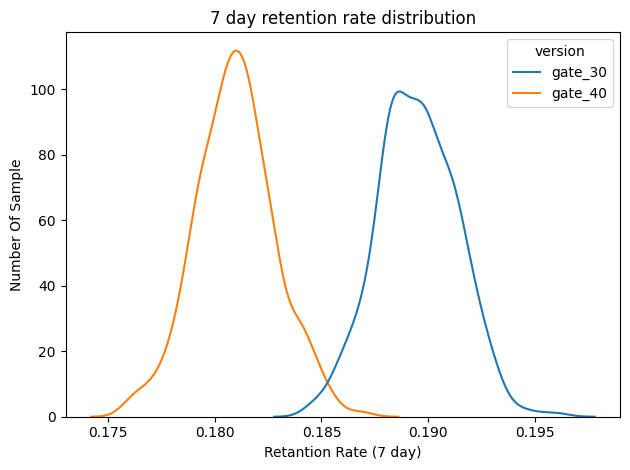

In [18]:
sns.kdeplot(data=df_7d)
plt.title("7 day retention rate distribution")
plt.xlabel('Retantion Rate (7 day)')
plt.ylabel('Number Of Sample')
plt.tight_layout()
plt.show()